In [24]:
import pandas as pd

In [25]:
df =pd.read_csv('../../data/raw/plant_ids.csv')

In [31]:
df.Date = pd.to_datetime(df.Date)

In [32]:
df = df.query('Monday_number==5').drop(columns=['Monday_number'])

In [33]:
def rolling_orders_6(x):
    return x.set_index('Date').sort_index().Invoiced_Quantity.rolling(6).apply(lambda x: len([i for i in x if i])).mean()>2

In [34]:
condition1 = df.groupby('customer_id').apply(rolling_orders_6)
condition1.sum()

/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_18659/4056260629.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  condition1 = df.groupby('customer_id').apply(rolling_orders_6)


np.int64(816)

In [35]:
unstack = df.groupby('customer_id').apply(lambda x: x.set_index('Date').sort_index().Invoiced_Quantity)

/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_18659/1430667726.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unstack = df.groupby('customer_id').apply(lambda x: x.set_index('Date').sort_index().Invoiced_Quantity)


In [36]:
invoices = unstack.reset_index().drop_duplicates().set_index(unstack.index.names).unstack(0)

In [37]:
orders_to_unstack = df.groupby('customer_id').apply(lambda x: x.set_index('Date').sort_index().Order_Quantity)

/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_18659/4271486556.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orders_to_unstack = df.groupby('customer_id').apply(lambda x: x.set_index('Date').sort_index().Order_Quantity)


In [38]:
orders = orders_to_unstack.reset_index().drop_duplicates().set_index(orders_to_unstack.index.names).unstack(1)

In [39]:
selection1 = invoices.Invoiced_Quantity.T[condition1].T

In [40]:
selection1_o = orders.Order_Quantity.T.loc[:,condition1].T

In [41]:
selection2 = selection1.T[selection1.tail(6).isna().sum()!=6].T

In [42]:
selection2_o = selection1_o[selection1_o.columns[selection1_o.columns.isin(list(selection2.columns))]]

In [43]:
import matplotlib.pyplot as plt

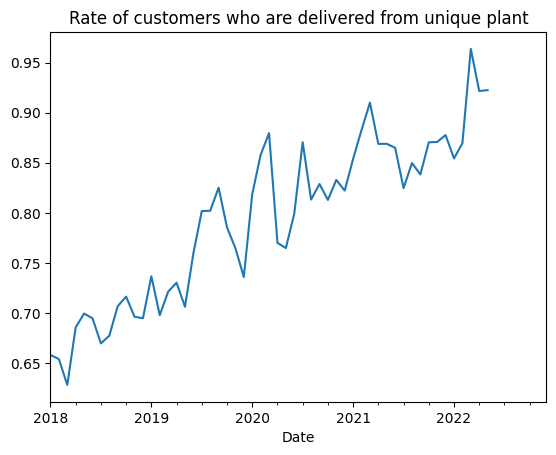

In [44]:
(selection2.sum(axis=1)/df.groupby('Date').Invoiced_Quantity.sum()).plot()
plt.title('Rate of customers who are delivered from unique plant')
plt.show()

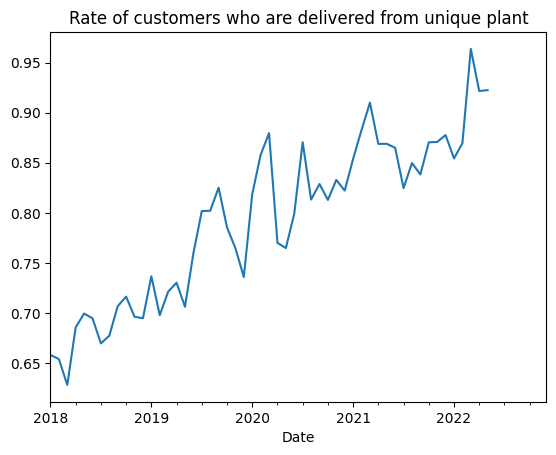

In [50]:
(zz1.sum(axis=1)/df.groupby('Date').Invoiced_Quantity.sum()).plot()
plt.title('Rate of customers who are delivered from unique plant')
plt.show()

In [45]:
print('Share of customers in the sampled demand is', str(round(selection2.shape[1]/df.customer_id.nunique()*100,2))+'%')

Share of customers in the sampled demand is 34.0%


In [51]:
print('Share of customers in the sampled demand is', str(round(zz1.shape[1]/df.customer_id.nunique()*100,2))+'%')


Share of customers in the sampled demand is 34.0%


In [27]:
def transform_data(df):
    """
    Transforms plant order data to analyze customer ordering patterns.
    
    This function processes plant order and invoice data by filtering for 
    specific days, analyzing rolling patterns of orders for each customer, 
    and returning filtered DataFrames of invoice and order quantities.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame with columns:
        - Date: Order/invoice date
        - Monday_number: Integer indicating which Monday of the month
        - customer_id: Customer identifier
        - Invoiced_Quantity: Quantity invoiced
        - Order_Quantity: Quantity ordered
    
    Returns:
    --------
    tuple of pandas.DataFrame
        - First DataFrame: Filtered invoice quantities by date and customer
        - Second DataFrame: Corresponding order quantities for the same customers
    """
    # Convert Date to datetime and filter for the 5th Monday
    df = df.copy()  # Avoid modifying the input DataFrame
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.query('Monday_number == 5').drop(columns=['Monday_number'])
    
    # Define function to check if customer meets rolling order criteria
    def rolling_orders_6(x):
        """Check if average non-zero invoices in rolling windows exceeds threshold"""
        ts = x.set_index('Date').sort_index().Invoiced_Quantity
        # More efficient way to count non-zero values in each window
        return ts.rolling(6).apply(lambda x: (x > 0).sum()).mean() > 2
    
    # Get customers meeting the condition
    condition1 = df.groupby('customer_id').apply(rolling_orders_6)
    
    # Process Invoiced_Quantity
    invoices_grouped = df.groupby('customer_id').apply(
        lambda x: x.set_index('Date').sort_index()['Invoiced_Quantity']
    )
    invoices = invoices_grouped.reset_index().drop_duplicates().set_index(
        invoices_grouped.index.names
    ).unstack(0)
    
    # Process Order_Quantity
    orders_grouped = df.groupby('customer_id').apply(
        lambda x: x.set_index('Date').sort_index()['Order_Quantity']
    )
    orders = orders_grouped.reset_index().drop_duplicates().set_index(
        orders_grouped.index.names
    ).unstack(1)
    
    # Filter to customers meeting condition1
    selection1 = invoices['Invoiced_Quantity'].T[condition1].T
    selection1_o = orders['Order_Quantity'].T.loc[:, condition1].T
    
    # Further filter customers based on recent activity
    selection2 = selection1.T[selection1.tail(6).isna().sum() != 6].T
    selection2_o = selection1_o[
        selection1_o.columns[selection1_o.columns.isin(list(selection2.columns))]
    ]
    
    return selection2, selection2_o

In [29]:
zz1, zz2 = transform_data(df)

/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_18659/798805788.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  condition1 = df.groupby('customer_id').apply(rolling_orders_6)
/var/folders/tj/c9x9f0j55b53skv8htzftqsh0000gn/T/ipykernel_18659/798805788.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  invoices_grouped = df.groupby('customer_id').apply(
/var/folders/tj/c9x9f0j55b53skv8htzftqs

In [30]:
zz1

customer_id,4,8,16,25,29,30,31,35,37,43,...,1497,1500,1503,1504,1505,1512,1514,1515,1516,1519
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,86.14,NaN,NaN,NaN,3723.880,2580.46,1975.06,3099.33,47.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01 00:00:00+00:00,64.36,25.62,23.75,58.80,3191.390,1983.79,1801.28,2849.85,71.25,23.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 00:00:00+00:00,88.60,25.04,NaN,NaN,3532.600,2457.81,2004.08,2882.54,47.50,23.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-01 00:00:00+00:00,67.00,NaN,NaN,19.56,2323.260,2085.88,1862.26,3008.65,71.25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-01 00:00:00+00:00,83.42,25.46,23.75,19.44,3177.560,2241.55,2225.64,712.13,40.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-01 00:00:00+00:00,87.04,25.02,NaN,59.28,3299.800,2361.76,1881.80,2823.93,71.25,23.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-07-01 00:00:00+00:00,108.06,25.08,NaN,59.68,3483.420,2658.11,1972.52,3165.73,95.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-01 00:00:00+00:00,85.10,25.20,NaN,58.76,3554.720,2656.00,2010.68,3290.96,47.50,23.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-09-01 00:00:00+00:00,91.00,NaN,NaN,19.76,3363.780,2261.84,1684.90,3228.59,118.75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
